# Projeto NPS Swift — Entrega 2
## Treinamento de Modelos, NPS Ajustado e Análises de Negócio

**Pré-requisitos:** Este notebook usa a `base_modelagem_limpa.csv` e as taxonomias manuais gerados na Entrega 1.

---

## 0. Setup e Carregamento

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
import joblib
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score
)
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.sparse import hstack, csr_matrix

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Versões principais
import sklearn, scipy
print(f"pandas: {pd.__version__}")
print(f"sklearn: {sklearn.__version__}")
print(f"scipy: {scipy.__version__}")


pandas: 2.2.2
sklearn: 1.8.0
scipy: 1.15.2


In [6]:
# Carregar dados
df = pd.read_csv(r'..\..\..\..\data\processed\base_modelagem_limpa.csv')
print(f"Base de modelagem: {len(df):,} registros")

# Carregar taxonomias anotadas (2 anotadores)
a1 = pd.read_excel(r'..\..\..\..\data\samples\manual_taxonomy\taxonomia_anotacao_manual_1.xlsx')
a2 = pd.read_excel(r'..\..\..\..\data\samples\manual_taxonomy\taxonomia_anotacao_manual_2.xlsx')

# Normalizar
a1['Categoria'] = a1['Categoria'].str.strip()
a2['Categoria'] = a2['Categoria'].str.strip()
a1['Sentimento'] = a1['Sentimento'].str.strip().str.capitalize()
a2['Sentimento'] = a2['Sentimento'].str.strip().str.capitalize()

# Consolidar: usar anotação do A1 como primária, A2 como validação
# Para treino, usamos A1 (Kappa 0.653 = substancial)
# Unificar categorias (absorver Variedade → Abastecimento, Limpeza → Estrutura/Loja)
cat_map = {
    'Variedade': 'Abastecimento',
    'Limpeza/Ambiente': 'Estrutura/Loja',
    'Outros ': 'Outros'  # trailing space
}
a1['Categoria'] = a1['Categoria'].replace(cat_map)
a2['Categoria'] = a2['Categoria'].replace(cat_map)

# Unificar Misto → tratar como Neutro para treino de sentimento
sent_map = {'Misto': 'Neutro'}
a1['Sentimento'] = a1['Sentimento'].replace(sent_map)
a2['Sentimento'] = a2['Sentimento'].replace(sent_map)

print(f"\nAnotação consolidada: {len(a1)} comentários")
print(f"Categorias finais: {sorted(a1['Categoria'].unique())}")
print(f"Sentimentos finais: {sorted(a1['Sentimento'].unique())}")
print(f"\nDistribuição Categoria:")
print(a1['Categoria'].value_counts())
print(f"\nDistribuição Sentimento:")
print(a1['Sentimento'].value_counts())

Base de modelagem: 111,087 registros

Anotação consolidada: 252 comentários
Categorias finais: ['Abastecimento', 'Atendimento', 'Entrega', 'Estrutura/Loja', 'Outros', 'Preço', 'Produto/Qualidade']
Sentimentos finais: ['Negativo', 'Neutro', 'Positivo']

Distribuição Categoria:
Categoria
Produto/Qualidade    60
Atendimento          44
Abastecimento        34
Entrega              32
Outros               31
Estrutura/Loja       26
Preço                25
Name: count, dtype: int64

Distribuição Sentimento:
Sentimento
Negativo    181
Positivo     37
Neutro       34
Name: count, dtype: int64


---
## 0.1 — Expansão do Dataset de Treino

Com apenas 252 exemplos anotados, o treino de modelos robustos é limitado. Estratégia:

1. **Sentimento:** Usar a nota NPS como proxy (decisão da Entrega 1, Opção C) para gerar labels automáticos na base de 111K, e validar com a amostra manual
2. **Categorização:** Usar os 252 exemplos anotados + semi-supervised labeling via keywords para expandir

In [7]:
# === SENTIMENTO: usar classificação NPS como proxy ===
# promotor → Positivo, neutro → Neutro, detrator → Negativo
sent_proxy_map = {
    'promotor': 'Positivo',
    'neutro': 'Neutro',
    'detrator': 'Negativo'
}
df['sentimento_proxy'] = df['classificacao'].map(sent_proxy_map)

print("=== Sentimento via proxy (nota NPS) ===")
print(df['sentimento_proxy'].value_counts())
print(f"\nTotal para treino de sentimento: {len(df):,}")

=== Sentimento via proxy (nota NPS) ===
sentimento_proxy
Positivo    84179
Neutro      15165
Negativo    11743
Name: count, dtype: int64

Total para treino de sentimento: 111,087


In [8]:
# === CATEGORIZAÇÃO: expandir com keywords ===
# Regras baseadas nos bigramas discriminativos da EDA + taxonomia manual
keyword_rules = {
    'Atendimento': ['atendimento', 'funcionário', 'funcionária', 'atendente', 'atenciosa',
                    'atencioso', 'educado', 'educada', 'caixa', 'fila', 'demora'],
    'Produto/Qualidade': ['carne dura', 'picanha', 'qualidade', 'vencido', 'estragado',
                          'gordura', 'gosto', 'sabor', 'embalagem', 'congelado', 'frango'],
    'Preço': ['preço', 'preços', 'caro', 'barato', 'promoção', 'promoções', 'desconto',
              'descontos', 'cupom', 'fidelidade'],
    'Abastecimento': ['falta', 'faltou', 'senti falta', 'sinto falta', 'acabou',
                       'estoque', 'reposição', 'variedade', 'opção', 'opções'],
    'Entrega': ['entrega', 'pedido', 'delivery', 'site', 'app', 'aplicativo', 'prazo',
                'chegou', 'receber', 'recebi', 'whatsapp'],
    'Estrutura/Loja': ['limpeza', 'limpa', 'suja', 'organização', 'organizada',
                        'estacionamento', 'ambiente', 'espaço', 'climatização', 'ar condicionado']
}

def classify_by_keywords(texto):
    texto_lower = str(texto).lower()
    scores = {}
    for cat, keywords in keyword_rules.items():
        score = sum(1 for kw in keywords if kw in texto_lower)
        if score > 0:
            scores[cat] = score
    if scores:
        return max(scores, key=scores.get)
    return 'Outros'

df['categoria_keyword'] = df['Comentario'].apply(classify_by_keywords)

print("=== Categorização via keywords (base completa) ===")
print(df['categoria_keyword'].value_counts())

# Validar keywords vs anotação manual
# Merge com anotação e medir concordância
merged_val = a1.merge(df[['Comentario', 'categoria_keyword']], on='Comentario', how='left')
merged_val = merged_val.dropna(subset=['categoria_keyword'])
if len(merged_val) > 0:
    concordancia = (merged_val['Categoria'] == merged_val['categoria_keyword']).mean() * 100
    print(f"\nConcordância keywords vs anotação manual: {concordancia:.1f}%")

=== Categorização via keywords (base completa) ===
categoria_keyword
Outros               34067
Atendimento          25726
Preço                19828
Produto/Qualidade    13924
Entrega               9305
Abastecimento         6418
Estrutura/Loja        1819
Name: count, dtype: int64

Concordância keywords vs anotação manual: 57.5%


---
---

# 1.1 — Modelo de Análise de Sentimento

## Arquitetura

- **Baseline:** TF-IDF (1-2 grams) + Logistic Regression (`class_weight='balanced'`)
- **Modelo principal:** TF-IDF avançado + engenharia de features + LinearSVC calibrado
- **Modelo opcional:** SetFit com `paraphrase-multilingual-MiniLM-L12-v2` para comparação sem fine-tuning completo de BERT
- **Granularidade:** Ternária (Positivo / Neutro / Negativo) — definida na Entrega 1
- **Ground truth:** Nota NPS como proxy + validação com amostra anotada

> Alteração aplicada: o BERTimbau foi substituído porque teve alto custo no Apple M4 (~36 min), F1 Macro 0.5794 e baixo desempenho na classe Neutro. A categorização segue mantida com TF-IDF + LinearSVC, pois já apresentou F1 Macro muito alto.


In [9]:
# === SPLIT TREINO/VALIDAÇÃO/TESTE ===
# Estratificado por sentimento
X = df['texto_limpo'].values
y = df['sentimento_proxy'].values

# 70% treino, 15% validação, 15% teste
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Split Sentimento:")
print(f"  Treino:    {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Validação: {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Teste:     {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nDistribuição no teste:")
print(pd.Series(y_test).value_counts())

Split Sentimento:
  Treino:    77,760 (70.0%)
  Validação: 16,663 (15.0%)
  Teste:     16,664 (15.0%)

Distribuição no teste:
Positivo    12627
Neutro       2275
Negativo     1762
Name: count, dtype: int64


In [10]:
# === BASELINE: TF-IDF + Logistic Regression ===
print("Treinando baseline (TF-IDF + LogReg)...")

baseline_sent = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=3)),
    ('clf', LogisticRegression(
        class_weight='balanced', max_iter=1000, C=1.0, random_state=42
    ))
])

baseline_sent.fit(X_train, y_train)
y_pred_baseline = baseline_sent.predict(X_test)

print("\n=== BASELINE SENTIMENTO: TF-IDF + Logistic Regression ===")
print(f"Acurácia: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"F1 Macro: {f1_score(y_test, y_pred_baseline, average='macro'):.4f}")
print(f"F1 Weighted: {f1_score(y_test, y_pred_baseline, average='weighted'):.4f}")
print(f"\nRelatório por classe:")
print(classification_report(y_test, y_pred_baseline, digits=4))

Treinando baseline (TF-IDF + LogReg)...

=== BASELINE SENTIMENTO: TF-IDF + Logistic Regression ===
Acurácia: 0.6941
F1 Macro: 0.5545
F1 Weighted: 0.7276

Relatório por classe:
              precision    recall  f1-score   support

    Negativo     0.4124    0.6107    0.4923      1762
      Neutro     0.2681    0.4681    0.3410      2275
    Positivo     0.9348    0.7465    0.8301     12627

    accuracy                         0.6941     16664
   macro avg     0.5385    0.6084    0.5545     16664
weighted avg     0.7886    0.6941    0.7276     16664



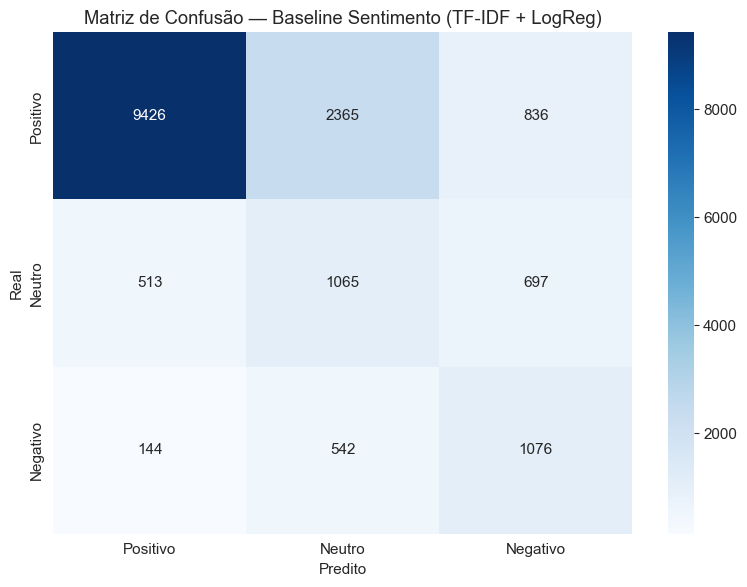


Erros mais frequentes (5097 de 16664):
real      pred    
Positivo  Neutro      2365
          Negativo     836
Neutro    Negativo     697
Negativo  Neutro       542
Neutro    Positivo     513
Negativo  Positivo     144
dtype: int64


In [11]:
# Matriz de confusão baseline
labels_sent = ['Positivo', 'Neutro', 'Negativo']
cm_baseline = confusion_matrix(y_test, y_pred_baseline, labels=labels_sent)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_baseline, annot=True, fmt='d', xticklabels=labels_sent,
            yticklabels=labels_sent, cmap='Blues', ax=ax)
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão — Baseline Sentimento (TF-IDF + LogReg)')
plt.tight_layout()
plt.show()

# Análise de erros
erros = pd.DataFrame({'texto': X_test, 'real': y_test, 'pred': y_pred_baseline})
erros_freq = erros[erros['real'] != erros['pred']]
print(f"\nErros mais frequentes ({len(erros_freq)} de {len(erros)}):")
print(erros_freq.groupby(['real', 'pred']).size().sort_values(ascending=False).head(6))

In [12]:
# === MODELO PRINCIPAL: TF-IDF AVANÇADO + FEATURES MANUAIS + LINEARSVC ===
# Substitui as células antigas do BERTimbau para reduzir custo de treino e melhorar a classe Neutro.

class FeatureExtrator(BaseEstimator, TransformerMixin):
    """
    Features manuais para complementar TF-IDF.
    O Neutro tende a aparecer em comentários curtos, ambíguos,
    sem marcadores fortes ou com sinais mistos positivos/negativos.
    """
    POSITIVOS = re.compile(
        r'\b(ótimo|excelente|perfeito|maravilhoso|adorei|amei|parabéns|'
        r'recomendo|satisfeito|feliz|lindo|incrível|top|show|demais|muito bom|'
        r'atendimento ótimo|super)\b', re.I
    )
    NEGATIVOS = re.compile(
        r'\b(péssimo|horrível|terrível|decepcionante|ruim|lamentável|'
        r'absurdo|vergonha|nunca mais|pior|desrespeit|demora|falta|'
        r'problema|reclamação|insatisfeito|não recomendo|frustr)\b', re.I
    )
    NEUTROS = re.compile(
        r'\b(ok|razoável|regular|mais ou menos|mediano|poderia|'
        r'às vezes|depende|não é o melhor|melhorar|falta pouco)\b', re.I
    )
    NEGACAO = re.compile(r'\b(não|nem|nunca|jamais|nada|nenhum)\b', re.I)

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        feats = []
        for texto in X:
            t = str(texto)
            n_palavras   = len(t.split())
            n_pos        = len(self.POSITIVOS.findall(t))
            n_neg        = len(self.NEGATIVOS.findall(t))
            n_neutro     = len(self.NEUTROS.findall(t))
            n_negacao    = len(self.NEGACAO.findall(t))
            n_exclamacao = t.count('!')
            ratio_pos    = n_pos / (n_neg + 1)          # dominância positiva
            ratio_neg    = n_neg / (n_pos + 1)          # dominância negativa
            tem_ambos    = int(n_pos > 0 and n_neg > 0) # sinal de ambiguidade/neutralidade
            feats.append([
                n_palavras, n_pos, n_neg, n_neutro, n_negacao,
                n_exclamacao, ratio_pos, ratio_neg, tem_ambos
            ])
        return np.array(feats, dtype=float)


class TFIDFComFeatures(BaseEstimator):
    """
    Combina TF-IDF sparse com features manuais dense em um único estimador.
    A combinação é feita manualmente com hstack para evitar problemas de compatibilidade
    entre matrizes sparse e dense dentro de um FeatureUnion comum.
    """
    def __init__(self, tfidf_params=None, C=0.3):
        self.tfidf_params = tfidf_params or {}
        self.C = C
        self.tfidf_ = TfidfVectorizer(**self.tfidf_params)
        self.feat_ = FeatureExtrator()
        self.clf_ = CalibratedClassifierCV(
            LinearSVC(
                class_weight='balanced',
                max_iter=5000,
                C=self.C,
                random_state=42,
            ),
            cv=3,
        )

    def fit(self, X, y):
        X_tfidf = self.tfidf_.fit_transform(X)
        X_feat  = csr_matrix(self.feat_.fit_transform(X))
        X_comb  = hstack([X_tfidf, X_feat])
        self.clf_.fit(X_comb, y)
        return self

    def predict(self, X):
        X_tfidf = self.tfidf_.transform(X)
        X_feat  = csr_matrix(self.feat_.transform(X))
        return self.clf_.predict(hstack([X_tfidf, X_feat]))

    def predict_proba(self, X):
        X_tfidf = self.tfidf_.transform(X)
        X_feat  = csr_matrix(self.feat_.transform(X))
        return self.clf_.predict_proba(hstack([X_tfidf, X_feat]))


print("Treinando Opção A: TF-IDF Avançado + Features Manuais + LinearSVC...")
print("Estimativa: deve completar em menos de 1 minuto no Apple M4.\n")

modelo_avancado = TFIDFComFeatures(
    tfidf_params=dict(
        max_features=20_000,
        ngram_range=(1, 3),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        strip_accents='unicode',
        analyzer='word',
    ),
    C=0.3,
)

modelo_avancado.fit(X_train, y_train)
y_pred_avancado = modelo_avancado.predict(X_test)

print("=== OPÇÃO A: TF-IDF Avançado + Features Manuais ===")
print(f"Acurácia   : {accuracy_score(y_test, y_pred_avancado):.4f}")
print(f"F1 Macro   : {f1_score(y_test, y_pred_avancado, average='macro'):.4f}")
print(f"F1 Weighted: {f1_score(y_test, y_pred_avancado, average='weighted'):.4f}")
print("\nRelatório por classe:")
print(classification_report(y_test, y_pred_avancado, digits=4))

print("\n=== COMPARAÇÃO COMPLETA ===")
header = f"{'Modelo':<40} | {'Acurácia':>9} | {'F1 Macro':>9} | {'F1 Weighted':>11}"
print(header)
print("-" * len(header))

resultados = [
    (
        "TF-IDF + LogReg (baseline)",
        accuracy_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_baseline, average='macro'),
        f1_score(y_test, y_pred_baseline, average='weighted'),
    ),
    ("BERTimbau fine-tuned anterior (~36 min)", 0.8032, 0.5794, 0.7825),
    (
        "TF-IDF Avançado + Features",
        accuracy_score(y_test, y_pred_avancado),
        f1_score(y_test, y_pred_avancado, average='macro'),
        f1_score(y_test, y_pred_avancado, average='weighted'),
    ),
]

for nome, acc, f1m, f1w in resultados:
    print(f"{nome:<40} | {acc:>9.4f} | {f1m:>9.4f} | {f1w:>11.4f}")

# Modelo padrão escolhido para as próximas células e para a inferência na base completa.
modelo_sentimento_final = modelo_avancado
y_pred_final = y_pred_avancado
nome_modelo_sentimento_final = "TF-IDF Avançado + Features"

joblib.dump(modelo_avancado, 'modelo_sentimento_avancado.pkl')
print("\nModelo salvo: modelo_sentimento_avancado.pkl")


Treinando Opção A: TF-IDF Avançado + Features Manuais + LinearSVC...
Estimativa: deve completar em menos de 1 minuto no Apple M4.

=== OPÇÃO A: TF-IDF Avançado + Features Manuais ===
Acurácia   : 0.7953
F1 Macro   : 0.5181
F1 Weighted: 0.7531

Relatório por classe:
              precision    recall  f1-score   support

    Negativo     0.5721    0.4325    0.4926      1762
      Neutro     0.4111    0.1046    0.1668      2275
    Positivo     0.8305    0.9704    0.8950     12627

    accuracy                         0.7953     16664
   macro avg     0.6046    0.5025    0.5181     16664
weighted avg     0.7459    0.7953    0.7531     16664


=== COMPARAÇÃO COMPLETA ===
Modelo                                   |  Acurácia |  F1 Macro | F1 Weighted
------------------------------------------------------------------------------
TF-IDF + LogReg (baseline)               |    0.6941 |    0.5545 |      0.7276
BERTimbau fine-tuned anterior (~36 min)  |    0.8032 |    0.5794 |      0.7825
TF-IDF A

In [13]:
# === OPÇÃO B: SETFIT (Sentence Transformers + head linear) ===
# Rode esta célula apenas se quiser comparar com uma alternativa semântica mais próxima do BERT,
# mas muito mais rápida que fine-tuning completo.

USAR_SETFIT = False  # Mude para True se quiser rodar esta alternativa.

if USAR_SETFIT:
    try:
        from setfit import SetFitModel, Trainer as SetFitTrainer, TrainingArguments as SetFitArgs
        from datasets import Dataset as HFDataset
    except ImportError:
        print("Instalando SetFit... (necessário apenas uma vez)")
        import subprocess
        subprocess.run(["pip", "install", "setfit", "-q"], check=True)
        from setfit import SetFitModel, Trainer as SetFitTrainer, TrainingArguments as SetFitArgs
        from datasets import Dataset as HFDataset

    MAX_POR_CLASSE = 2000
    CLASSES = ['Positivo', 'Neutro', 'Negativo']

    indices_treino = []
    y_train_series = pd.Series(y_train)
    for cls in CLASSES:
        idx_cls = y_train_series[y_train_series == cls].index.tolist()
        n = min(MAX_POR_CLASSE, len(idx_cls))
        idx_samp = pd.Series(idx_cls).sample(n, random_state=42).tolist()
        indices_treino.extend(idx_samp)

    X_sf = [X_train[i] for i in indices_treino]
    y_sf = [y_train[i] for i in indices_treino]

    train_ds = HFDataset.from_dict({"text": X_sf, "label": y_sf})
    test_ds = HFDataset.from_dict({
        "text": list(X_test[:3000]),
        "label": list(y_test[:3000]),
    })

    print("Carregando SetFit (paraphrase-multilingual-MiniLM-L12-v2)...")
    print(f"Treino: {len(X_sf):,} amostras balanceadas | Teste parcial: 3.000")
    print("Estimativa: ~3-5 minutos no Apple M4 — versus ~36 min do BERTimbau.\n")

    setfit_model = SetFitModel.from_pretrained(
        "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
        labels=CLASSES,
    )

    setfit_args = SetFitArgs(
        batch_size=32,
        num_epochs=1,
        num_iterations=20,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
    )

    setfit_trainer = SetFitTrainer(
        model=setfit_model,
        args=setfit_args,
        train_dataset=train_ds,
        eval_dataset=test_ds,
        metric="f1",
        metric_kwargs={"average": "macro"},
    )

    setfit_trainer.train()

    y_pred_setfit = setfit_model.predict(list(X_test))

    print("\n=== OPÇÃO B: SetFit (Multilingual MiniLM) ===")
    print(f"Acurácia   : {accuracy_score(y_test, y_pred_setfit):.4f}")
    print(f"F1 Macro   : {f1_score(y_test, y_pred_setfit, average='macro'):.4f}")
    print(f"F1 Weighted: {f1_score(y_test, y_pred_setfit, average='weighted'):.4f}")
    print(classification_report(y_test, y_pred_setfit, digits=4))

    setfit_model.save_pretrained('./modelo_sentimento_setfit')
    print("Modelo SetFit salvo: ./modelo_sentimento_setfit/")

    # Caso o SetFit supere a Opção A, as próximas células passam a usá-lo.
    modelo_sentimento_final = setfit_model
    y_pred_final = y_pred_setfit
    nome_modelo_sentimento_final = "SetFit (Multilingual MiniLM)"
else:
    print("SetFit não executado. Mantendo Opção A como modelo final de sentimento.")


SetFit não executado. Mantendo Opção A como modelo final de sentimento.


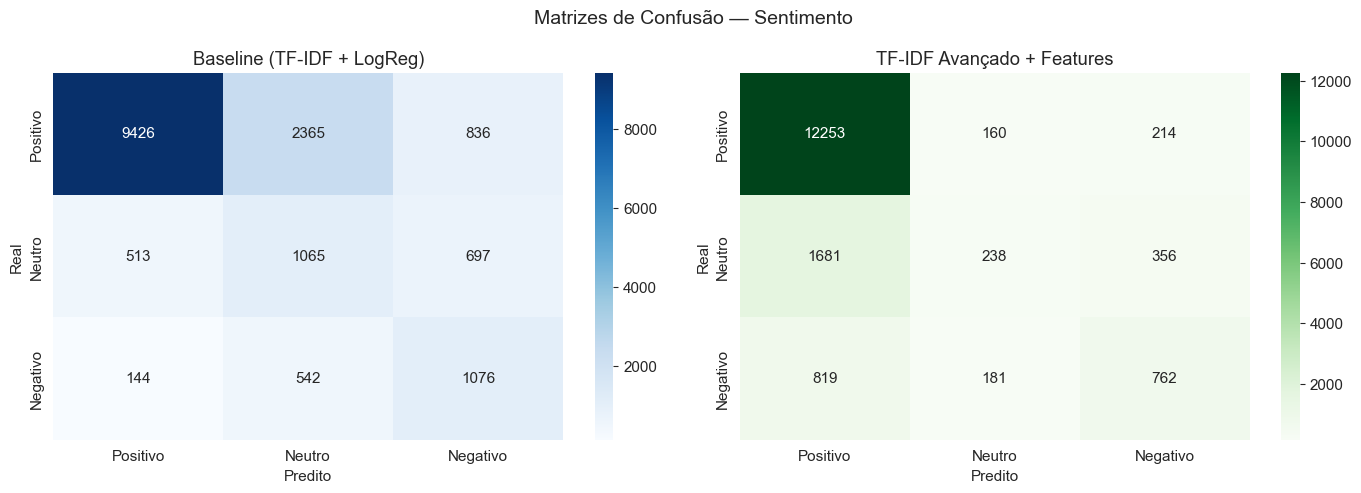


Erros mais frequentes (3411 de 16664):
real      pred    
Neutro    Positivo    1681
Negativo  Positivo     819
Neutro    Negativo     356
Positivo  Negativo     214
Negativo  Neutro       181
Positivo  Neutro       160
dtype: int64

Modelo baseline salvo: modelo_sentimento_baseline.pkl
Modelo final salvo: modelo_sentimento_final.pkl
Use joblib.load('modelo_sentimento_final.pkl') no backend.


In [14]:
# === ANÁLISE DE ERROS DO MODELO DE SENTIMENTO ESCOLHIDO ===
# Por padrão usa a Opção A. Se a Opção B for executada com USAR_SETFIT=True,
# esta célula usa automaticamente o SetFit como modelo final.

labels_sent = ['Positivo', 'Neutro', 'Negativo']
cm_final = confusion_matrix(y_test, y_pred_final, labels=labels_sent)
cm_baseline_plot = confusion_matrix(y_test, y_pred_baseline, labels=labels_sent)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm_baseline_plot,
    annot=True,
    fmt='d',
    xticklabels=labels_sent,
    yticklabels=labels_sent,
    cmap='Blues',
    ax=axes[0],
)
axes[0].set_title('Baseline (TF-IDF + LogReg)')
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')

sns.heatmap(
    cm_final,
    annot=True,
    fmt='d',
    xticklabels=labels_sent,
    yticklabels=labels_sent,
    cmap='Greens',
    ax=axes[1],
)
axes[1].set_title(nome_modelo_sentimento_final)
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')

plt.suptitle('Matrizes de Confusão — Sentimento', fontsize=14)
plt.tight_layout()
plt.show()

# Análise de erros
erros = pd.DataFrame({'texto': X_test, 'real': y_test, 'pred': y_pred_final})
erros_df = erros[erros['real'] != erros['pred']]
print(f"\nErros mais frequentes ({len(erros_df)} de {len(erros)}):")
print(erros_df.groupby(['real', 'pred']).size().sort_values(ascending=False).head(6))

# Persistência dos modelos para backend/inferência.
joblib.dump(baseline_sent, 'modelo_sentimento_baseline.pkl')
print("\nModelo baseline salvo: modelo_sentimento_baseline.pkl")

if isinstance(modelo_sentimento_final, TFIDFComFeatures):
    joblib.dump(modelo_sentimento_final, 'modelo_sentimento_final.pkl')
    print("Modelo final salvo: modelo_sentimento_final.pkl")
    print("Use joblib.load('modelo_sentimento_final.pkl') no backend.")
else:
    modelo_sentimento_final.save_pretrained('./modelo_sentimento_final_setfit')
    print("Modelo final SetFit salvo: ./modelo_sentimento_final_setfit/")
    print("Use SetFitModel.from_pretrained('./modelo_sentimento_final_setfit') no backend.")


---
## 1.2 — Modelo de Categorização

**Arquitetura:** TF-IDF + LinearSVC calibrado como modelo principal mantido  
**Classificação:** Single-label, 7 categorias  
**Treino:** Dataset expandido via keywords (validado contra anotação manual)

> Alteração aplicada: a categorização foi mantida no paradigma TF-IDF + LinearSVC, pois já apresentou F1 Macro alto e não exige substituição por BERTimbau.


In [15]:
# Dataset para categorização
# Usar keywords como labels (já validadas ~60% concordância com manual)
# + incluir os 252 exemplos manuais com peso extra

# Base expandida: keywords
X_cat = df['texto_limpo'].values
y_cat = df['categoria_keyword'].values

# Split estratificado
X_cat_train, X_cat_temp, y_cat_train, y_cat_temp = train_test_split(
    X_cat, y_cat, test_size=0.3, random_state=42, stratify=y_cat
)
X_cat_val, X_cat_test, y_cat_val, y_cat_test = train_test_split(
    X_cat_temp, y_cat_temp, test_size=0.5, random_state=42, stratify=y_cat_temp
)

print(f"Split Categorização:")
print(f"  Treino:    {len(X_cat_train):,}")
print(f"  Validação: {len(X_cat_val):,}")
print(f"  Teste:     {len(X_cat_test):,}")
print(f"\nDistribuição no teste:")
print(pd.Series(y_cat_test).value_counts())

Split Categorização:
  Treino:    77,760
  Validação: 16,663
  Teste:     16,664

Distribuição no teste:
Outros               5110
Atendimento          3859
Preço                2975
Produto/Qualidade    2089
Entrega              1396
Abastecimento         962
Estrutura/Loja        273
Name: count, dtype: int64


In [16]:
# === BASELINE CATEGORIZAÇÃO: TF-IDF + LinearSVC ===
print("Treinando baseline categorização (TF-IDF + LinearSVC)...")

baseline_cat = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=3)),
    ('clf', LinearSVC(class_weight='balanced', max_iter=2000, random_state=42))
])

baseline_cat.fit(X_cat_train, y_cat_train)
y_cat_pred_baseline = baseline_cat.predict(X_cat_test)

labels_cat = sorted(df['categoria_keyword'].unique())

print("\n=== BASELINE CATEGORIZAÇÃO: TF-IDF + LinearSVC ===")
print(f"Acurácia: {accuracy_score(y_cat_test, y_cat_pred_baseline):.4f}")
print(f"F1 Macro: {f1_score(y_cat_test, y_cat_pred_baseline, average='macro'):.4f}")
print(f"F1 Weighted: {f1_score(y_cat_test, y_cat_pred_baseline, average='weighted'):.4f}")
print(f"\nRelatório por classe:")
print(classification_report(y_cat_test, y_cat_pred_baseline, digits=4))

Treinando baseline categorização (TF-IDF + LinearSVC)...

=== BASELINE CATEGORIZAÇÃO: TF-IDF + LinearSVC ===
Acurácia: 0.9735
F1 Macro: 0.9603
F1 Weighted: 0.9735

Relatório por classe:
                   precision    recall  f1-score   support

    Abastecimento     0.9529    0.9470    0.9499       962
      Atendimento     0.9829    0.9673    0.9751      3859
          Entrega     0.9411    0.9606    0.9507      1396
   Estrutura/Loja     0.8920    0.9377    0.9143       273
           Outros     0.9769    0.9953    0.9860      5110
            Preço     0.9873    0.9687    0.9779      2975
Produto/Qualidade     0.9715    0.9641    0.9678      2089

         accuracy                         0.9735     16664
        macro avg     0.9578    0.9630    0.9603     16664
     weighted avg     0.9737    0.9735    0.9735     16664



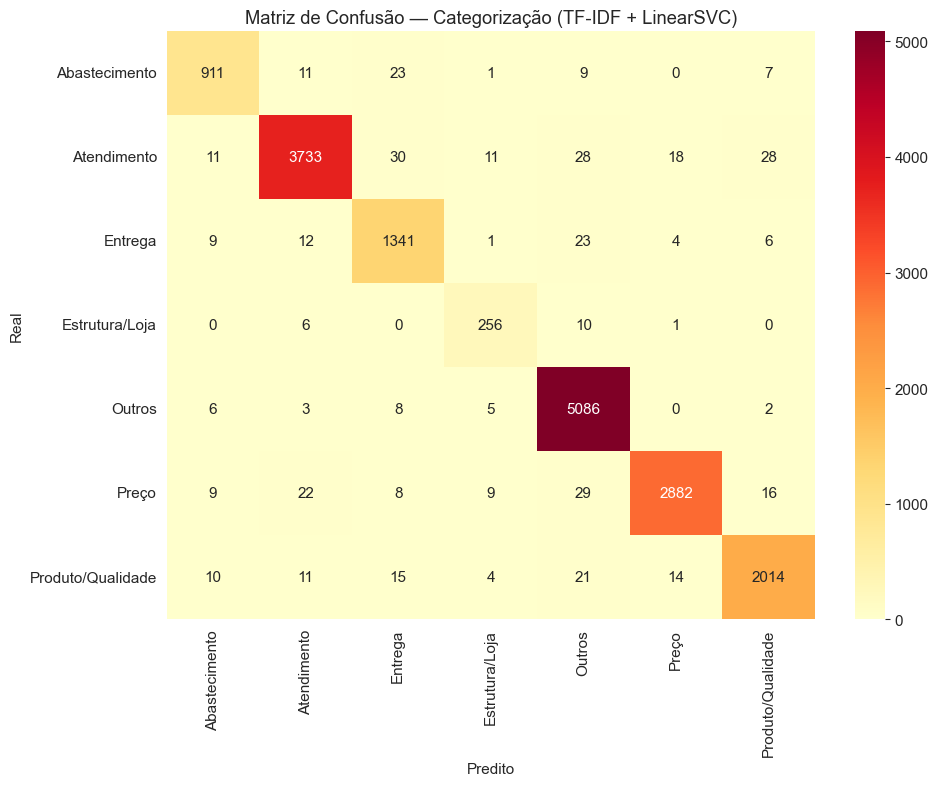


Categorias com PIOR F1:
  Estrutura/Loja: F1=0.914
  Abastecimento: F1=0.950
  Entrega: F1=0.951


In [17]:
# Matriz de confusão categorização
cm_cat = confusion_matrix(y_cat_test, y_cat_pred_baseline, labels=labels_cat)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_cat, annot=True, fmt='d', xticklabels=labels_cat,
            yticklabels=labels_cat, cmap='YlOrRd', ax=ax)
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão — Categorização (TF-IDF + LinearSVC)')
plt.tight_layout()
plt.show()

# Análise de categorias com pior performance
report_dict = classification_report(y_cat_test, y_cat_pred_baseline, output_dict=True)
cat_f1 = {k: v['f1-score'] for k, v in report_dict.items() if k in labels_cat}
cat_f1_sorted = sorted(cat_f1.items(), key=lambda x: x[1])
print("\nCategorias com PIOR F1:")
for cat, f1 in cat_f1_sorted[:3]:
    print(f"  {cat}: F1={f1:.3f}")

In [18]:
# Salvar modelo baseline categorização
joblib.dump(baseline_cat, 'modelo_categorizacao_baseline.pkl')
print("Modelo baseline categorização salvo: modelo_categorizacao_baseline.pkl")

Modelo baseline categorização salvo: modelo_categorizacao_baseline.pkl


---
## 1.3 — Inferência na Base Completa

In [19]:
# Rodar inferência na base completa de 111K comentários
print("Rodando inferência na base completa...")

# Sentimento: usa o modelo final escolhido na etapa 1.1
# - padrão: TF-IDF Avançado + Features
# - opcional: SetFit, caso a célula da Opção B tenha sido executada com USAR_SETFIT=True
modelo_inferencia_sentimento = modelo_sentimento_final

df['sentimento_pred'] = modelo_inferencia_sentimento.predict(df['texto_limpo'])

# Categorização: manter TF-IDF + LinearSVC
# Este modelo já apresentou alto desempenho e segue como baseline/modelo principal de categoria.
df['categoria_pred'] = baseline_cat.predict(df['texto_limpo'])

print(f"Inferência completa: {len(df):,} comentários classificados")
print("\nDistribuição Sentimento (predito):")
print(df['sentimento_pred'].value_counts())
print("\nDistribuição Categoria (predito):")
print(df['categoria_pred'].value_counts())


Rodando inferência na base completa...
Inferência completa: 111,087 comentários classificados

Distribuição Sentimento (predito):
sentimento_pred
Positivo    97773
Negativo     9388
Neutro       3926
Name: count, dtype: int64

Distribuição Categoria (predito):
categoria_pred
Outros               34625
Atendimento          25405
Preço                19596
Produto/Qualidade    13826
Entrega               9371
Abastecimento         6418
Estrutura/Loja        1846
Name: count, dtype: int64


In [20]:
# Salvar base com predições para uso no backend/dashboard
df.to_csv('base_com_predicoes.csv', index=False, encoding='utf-8-sig')
print(f"Base com predições salva: base_com_predicoes.csv ({len(df):,} registros)")

Base com predições salva: base_com_predicoes.csv (111,087 registros)


---
---

# 2. Novo Cálculo de NPS com Incorporação do Comentário

## 2.1 — Proposta de Fórmula

**NPS Ajustado** = NPS Tradicional + Ajuste por Sentimento do Comentário

A ideia: quando o sentimento do comentário **diverge** da nota, ajustar o NPS para refletir a experiência real descrita no texto.

**Fórmula:**

```
NPS_ajustado = ((P_ajustado - D_ajustado) / Total) × 100

Onde:
- Promotor com sentimento Negativo → reclassificado como Neutro
- Detrator com sentimento Positivo → reclassificado como Neutro  
- Neutro com sentimento Negativo forte → reclassificado como Detrator
- Neutro com sentimento Positivo forte → reclassificado como Promotor
```

Comentários sem texto (46.5% da base) mantêm classificação original pela nota.

In [21]:
# Implementar NPS Ajustado
def classificacao_ajustada(row):
    """Reclassifica com base na divergência nota vs sentimento do texto"""
    classif = row['classificacao']
    sent = row.get('sentimento_pred', None)
    
    # Sem predição de sentimento → manter original
    if pd.isna(sent) or sent == '':
        return classif
    
    # Promotor com texto negativo → rebaixa para neutro
    if classif == 'promotor' and sent == 'Negativo':
        return 'neutro'
    
    # Detrator com texto positivo → eleva para neutro
    if classif == 'detrator' and sent == 'Positivo':
        return 'neutro'
    
    # Neutro com texto negativo → rebaixa para detrator
    if classif == 'neutro' and sent == 'Negativo':
        return 'detrator'
    
    # Neutro com texto positivo → eleva para promotor
    if classif == 'neutro' and sent == 'Positivo':
        return 'promotor'
    
    return classif

df['classificacao_ajustada'] = df.apply(classificacao_ajustada, axis=1)

# Calcular NPS tradicional vs ajustado
total = len(df)
# Tradicional
p_trad = (df['classificacao'] == 'promotor').sum()
d_trad = (df['classificacao'] == 'detrator').sum()
nps_trad = (p_trad - d_trad) / total * 100

# Ajustado
p_ajust = (df['classificacao_ajustada'] == 'promotor').sum()
d_ajust = (df['classificacao_ajustada'] == 'detrator').sum()
nps_ajust = (p_ajust - d_ajust) / total * 100

print("=== NPS GERAL ===")
print(f"  NPS Tradicional: {nps_trad:.1f}%")
print(f"  NPS Ajustado:    {nps_ajust:.1f}%")
print(f"  Diferença:       {nps_ajust - nps_trad:+.1f} pontos")

=== NPS GERAL ===
  NPS Tradicional: 65.2%
  NPS Ajustado:    76.4%
  Diferença:       +11.2 pontos


In [22]:
# 2.2 — Análise de Impacto

# Divergências nota vs sentimento
divergencias = df[df['classificacao'] != df['classificacao_ajustada']]
pct_diverge = len(divergencias) / len(df) * 100

print(f"=== ANÁLISE DE IMPACTO ===")
print(f"  Avaliações com divergência nota/sentimento: {len(divergencias):,} ({pct_diverge:.1f}%)")
print(f"\n  Detalhamento das reclassificações:")
recl = divergencias.groupby(['classificacao', 'classificacao_ajustada']).size()
for (orig, nova), n in recl.items():
    print(f"    {orig} → {nova}: {n:,}")

# NPS por loja: quantas mudam de faixa?
nps_loja_trad = df.groupby('CentroNv2').apply(
    lambda x: (x['classificacao']=='promotor').sum() / len(x) * 100 -
              (x['classificacao']=='detrator').sum() / len(x) * 100
).rename('nps_trad')

nps_loja_ajust = df.groupby('CentroNv2').apply(
    lambda x: (x['classificacao_ajustada']=='promotor').sum() / len(x) * 100 -
              (x['classificacao_ajustada']=='detrator').sum() / len(x) * 100
).rename('nps_ajust')

nps_compare = pd.concat([nps_loja_trad, nps_loja_ajust], axis=1)
nps_compare['diff'] = nps_compare['nps_ajust'] - nps_compare['nps_trad']

# Mudanças de faixa (positivo >50, neutro 0-50, negativo <0)
def faixa_nps(nps):
    if nps >= 50: return 'Excelente'
    elif nps >= 0: return 'Aperfeiçoamento'
    return 'Crítico'

nps_compare['faixa_trad'] = nps_compare['nps_trad'].apply(faixa_nps)
nps_compare['faixa_ajust'] = nps_compare['nps_ajust'].apply(faixa_nps)
mudaram_faixa = nps_compare[nps_compare['faixa_trad'] != nps_compare['faixa_ajust']]

print(f"\n  Lojas que mudaram de faixa de NPS: {len(mudaram_faixa)} de {len(nps_compare)}")
if len(mudaram_faixa) > 0:
    print(mudaram_faixa[['nps_trad', 'nps_ajust', 'faixa_trad', 'faixa_ajust']].to_string())

# Casos extremos
print(f"\n  Top 10 lojas com MAIOR divergência (ajuste pra baixo):")
print(nps_compare.nsmallest(10, 'diff')[['nps_trad', 'nps_ajust', 'diff']].to_string())

=== ANÁLISE DE IMPACTO ===
  Avaliações com divergência nota/sentimento: 18,240 (16.4%)

  Detalhamento das reclassificações:
    detrator → neutro: 4,621
    neutro → detrator: 1,913
    neutro → promotor: 10,713
    promotor → neutro: 993

  Lojas que mudaram de faixa de NPS: 5 de 228
                            nps_trad  nps_ajust       faixa_trad faixa_ajust
CentroNv2                                                                   
L5014-ROUXINOL (0567)      48.626374  67.582418  Aperfeiçoamento   Excelente
L5017-LEOPOLDINA (0576)    42.968750  60.156250  Aperfeiçoamento   Excelente
L5081-VILA OLIMPIA (1345)  44.392523  62.616822  Aperfeiçoamento   Excelente
L5107-MANDAQUI (1521)      46.864686  62.706271  Aperfeiçoamento   Excelente
L5200-JUVENTUS             42.857143  58.385093  Aperfeiçoamento   Excelente

  Top 10 lojas com MAIOR divergência (ajuste pra baixo):
                             nps_trad  nps_ajust      diff
CentroNv2                                               

---
---

# 3. Análises de Negócio

## 3.1 — Comparativo: REGULAR vs TOCADORA (Germinare)

=== COMPARATIVO: REGULAR vs TOCADORA ===
    Flag  Total  NPS_Trad  NPS_Ajust  Pct_Positivo  Pct_Neutro  Pct_Negativo    Top_Problema_1    Top_Problema_2 Top_Problema_3
 REGULAR  84883 66.849664  77.723455     88.651438    3.401152      7.947410 Produto/Qualidade           Entrega    Atendimento
TOCADORA  25868 59.699242  71.980826     85.901500    3.977888     10.120612           Entrega Produto/Qualidade    Atendimento


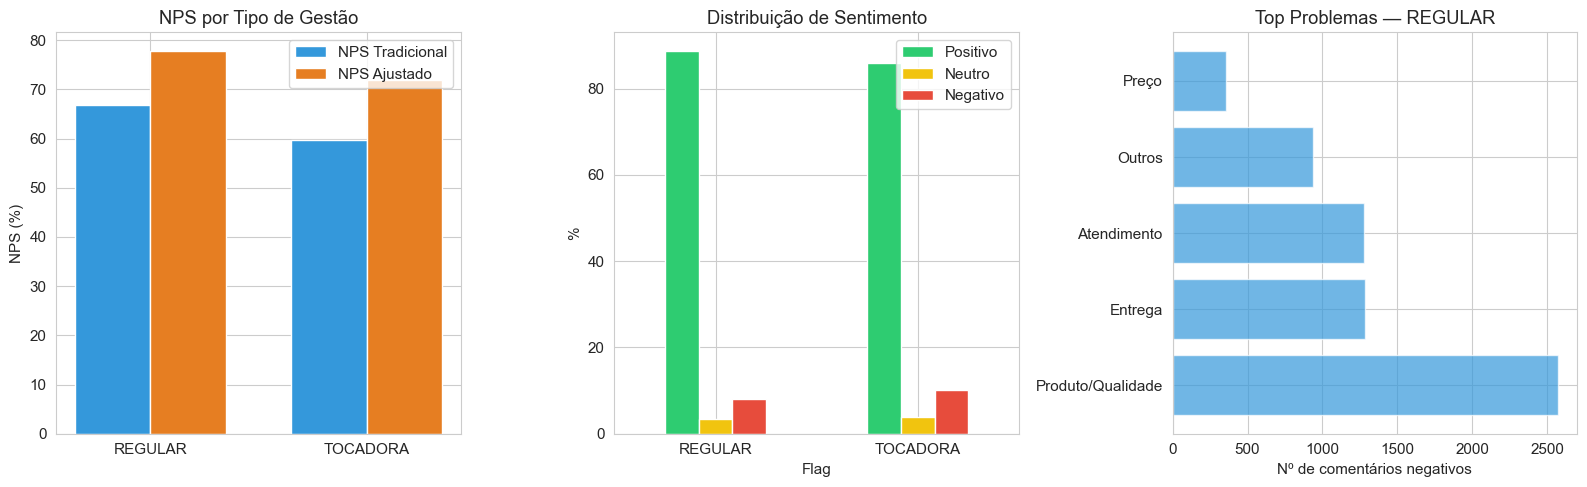

In [23]:
# Comparativo por tipo de gestão
df_flag = df[df['Flag'].isin(['REGULAR', 'TOCADORA'])].copy()

comparativo = []
for flag in ['REGULAR', 'TOCADORA']:
    sub = df_flag[df_flag['Flag'] == flag]
    n = len(sub)
    
    # NPS Tradicional
    p = (sub['classificacao'] == 'promotor').sum()
    d = (sub['classificacao'] == 'detrator').sum()
    nps_t = (p - d) / n * 100
    
    # NPS Ajustado
    p_a = (sub['classificacao_ajustada'] == 'promotor').sum()
    d_a = (sub['classificacao_ajustada'] == 'detrator').sum()
    nps_a = (p_a - d_a) / n * 100
    
    # Sentimentos
    sent_dist = sub['sentimento_pred'].value_counts(normalize=True) * 100
    
    # Categorias de problemas (sentimento negativo)
    problemas = sub[sub['sentimento_pred'] == 'Negativo']['categoria_pred'].value_counts()
    
    comparativo.append({
        'Flag': flag,
        'Total': n,
        'NPS_Trad': nps_t,
        'NPS_Ajust': nps_a,
        'Pct_Positivo': sent_dist.get('Positivo', 0),
        'Pct_Neutro': sent_dist.get('Neutro', 0),
        'Pct_Negativo': sent_dist.get('Negativo', 0),
        'Top_Problema_1': problemas.index[0] if len(problemas) > 0 else 'N/A',
        'Top_Problema_2': problemas.index[1] if len(problemas) > 1 else 'N/A',
        'Top_Problema_3': problemas.index[2] if len(problemas) > 2 else 'N/A',
    })

comp_df = pd.DataFrame(comparativo)
print("=== COMPARATIVO: REGULAR vs TOCADORA ===")
print(comp_df.to_string(index=False))

# Visualização
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# NPS
x = np.arange(2)
w = 0.35
axes[0].bar(x - w/2, comp_df['NPS_Trad'], w, label='NPS Tradicional', color='#3498db')
axes[0].bar(x + w/2, comp_df['NPS_Ajust'], w, label='NPS Ajustado', color='#e67e22')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comp_df['Flag'])
axes[0].set_ylabel('NPS (%)')
axes[0].set_title('NPS por Tipo de Gestão')
axes[0].legend()

# Sentimento
sent_data = comp_df[['Flag', 'Pct_Positivo', 'Pct_Neutro', 'Pct_Negativo']].set_index('Flag')
sent_data.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#f1c40f', '#e74c3c'])
axes[1].set_title('Distribuição de Sentimento')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Positivo', 'Neutro', 'Negativo'])

# Top problemas
for i, flag in enumerate(['REGULAR', 'TOCADORA']):
    sub = df_flag[(df_flag['Flag'] == flag) & (df_flag['sentimento_pred'] == 'Negativo')]
    cat_counts = sub['categoria_pred'].value_counts().head(5)
    if i == 0:
        axes[2].barh(cat_counts.index, cat_counts.values, alpha=0.7, label='REGULAR', color='#3498db')
    # Sobrepor seria confuso, mostrar só texto

axes[2].set_title('Top Problemas — REGULAR')
axes[2].set_xlabel('Nº de comentários negativos')
plt.tight_layout()
plt.show()

## 3.2 — Principais Problemas e Elogios Gerais

In [24]:
# Top 5 categorias de PROBLEMAS (detratores + neutros com sentimento negativo)
problemas_geral = df[df['sentimento_pred'] == 'Negativo']['categoria_pred'].value_counts()
elogios_geral = df[df['sentimento_pred'] == 'Positivo']['categoria_pred'].value_counts()

print("=== TOP 5 CATEGORIAS DE PROBLEMAS ===")
for i, (cat, n) in enumerate(problemas_geral.head(5).items(), 1):
    pct = n / problemas_geral.sum() * 100
    print(f"\n{i}. {cat} ({n:,} comentários, {pct:.1f}%)")
    exemplos = df[(df['sentimento_pred']=='Negativo') & (df['categoria_pred']==cat)]['Comentario'].sample(3, random_state=42)
    for ex in exemplos:
        print(f"   > {ex[:120]}")

print("\n\n=== TOP 5 CATEGORIAS DE ELOGIOS ===")
for i, (cat, n) in enumerate(elogios_geral.head(5).items(), 1):
    pct = n / elogios_geral.sum() * 100
    print(f"\n{i}. {cat} ({n:,} comentários, {pct:.1f}%)")
    exemplos = df[(df['sentimento_pred']=='Positivo') & (df['categoria_pred']==cat)]['Comentario'].sample(3, random_state=42)
    for ex in exemplos:
        print(f"   > {ex[:120]}")

=== TOP 5 CATEGORIAS DE PROBLEMAS ===

1. Produto/Qualidade (3,301 comentários, 35.2%)
   > Picanhas mesmo senda a ponta a maioria dura, outros produtos ok, só picanha q não estou comprando
   > Atendimento e o pessoal da loja tudo certo, super bem! Mas os produtos estão com uma qualidade horrível, claramente foi 
   > Péssimo, comprei uma picanha ontem "ponta de agulha", extremamente dura, não recomendo! Procurei paleta de cordeiro, sem

2. Entrega (2,035 comentários, 21.7%)
   > Bom dia ! No domingo passado realizei uma compra às 08:50 hs e acertei o frete para entrega em mesmo dia, porém só fui r
   > O produto veio errado,e ainda me fizeram responder, que o produto tinha sido entregue, deveria ter controle do que sai p
   > Pessimo, estou esperando o estorno da compra efetuada, pra receber foi rápido…,

3. Atendimento (1,810 comentários, 19.3%)
   > Tirando esses 0péssimos funcionários daí. Se não for reparado( pela segunda vez) os danos que tive, não compro mais de v
   > Fiquei b

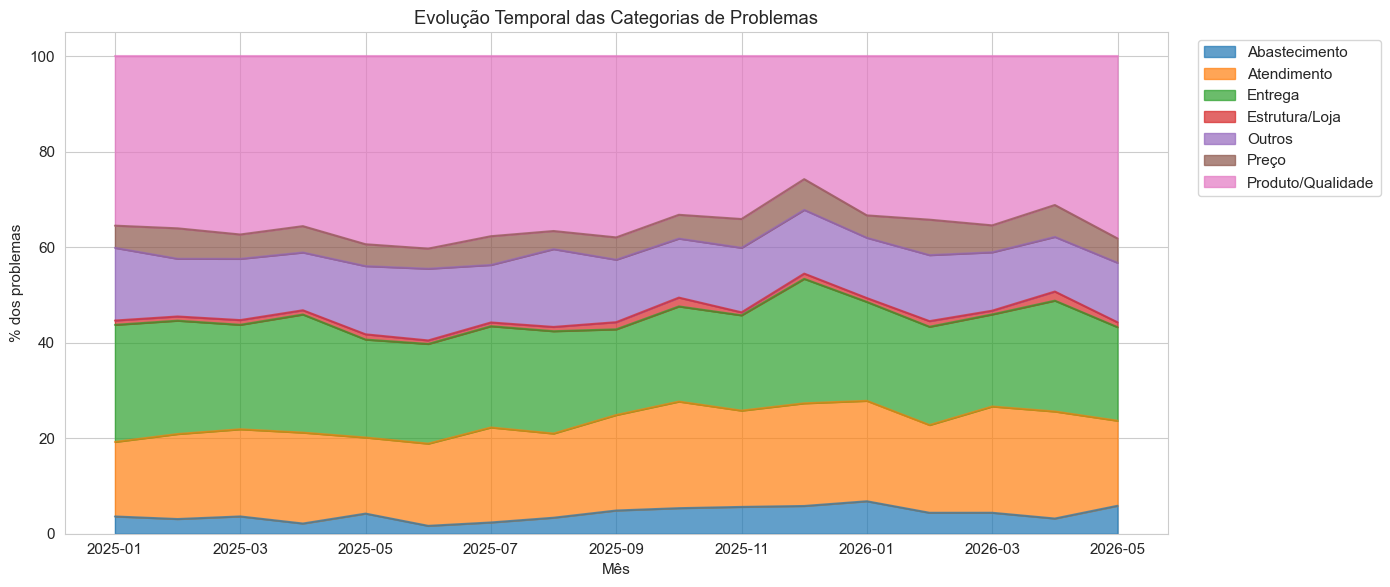

In [25]:
# Evolução temporal das categorias de problemas
df_neg = df[df['sentimento_pred'] == 'Negativo'].copy()
temporal_cat = df_neg.groupby(['mes_ano', 'categoria_pred']).size().unstack(fill_value=0)
temporal_cat_pct = temporal_cat.div(temporal_cat.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
temporal_cat_pct.plot(kind='area', stacked=True, ax=ax, alpha=0.7)
ax.set_title('Evolução Temporal das Categorias de Problemas')
ax.set_xlabel('Mês')
ax.set_ylabel('% dos problemas')
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
plt.tight_layout()
plt.show()

## 3.3 — Análise por Loja

In [26]:
# Resumo por loja
loja_resumo = df.groupby('CentroNv2').apply(lambda x: pd.Series({
    'NPS_Trad': ((x['classificacao']=='promotor').sum() - (x['classificacao']=='detrator').sum()) / len(x) * 100,
    'NPS_Ajust': ((x['classificacao_ajustada']=='promotor').sum() - (x['classificacao_ajustada']=='detrator').sum()) / len(x) * 100,
    'Sentimento_Medio': x['sentimento_pred'].map({'Positivo': 1, 'Neutro': 0, 'Negativo': -1}).mean(),
    'Top_Problema': x[x['sentimento_pred']=='Negativo']['categoria_pred'].mode().iloc[0] if len(x[x['sentimento_pred']=='Negativo']) > 0 else 'N/A',
    'Top_Elogio': x[x['sentimento_pred']=='Positivo']['categoria_pred'].mode().iloc[0] if len(x[x['sentimento_pred']=='Positivo']) > 0 else 'N/A',
    'Total_Comentarios': len(x),
    'Pct_Negativo': (x['sentimento_pred']=='Negativo').mean() * 100,
    'Flag': x['Flag'].mode().iloc[0]
})).reset_index()

# Flag de alerta: NPS ajustado muito diferente do tradicional
loja_resumo['Diff_NPS'] = loja_resumo['NPS_Ajust'] - loja_resumo['NPS_Trad']
loja_resumo['Alerta'] = loja_resumo['Diff_NPS'].abs() > loja_resumo['Diff_NPS'].std() * 1.5

print(f"=== RESUMO POR LOJA ({len(loja_resumo)} lojas) ===")
print(f"Lojas com alerta (divergência NPS significativa): {loja_resumo['Alerta'].sum()}")
print(f"\nTop 10 lojas com MAIOR divergência negativa (NPS inflado pela nota):")
print(loja_resumo.nsmallest(10, 'Diff_NPS')[['CentroNv2', 'NPS_Trad', 'NPS_Ajust', 'Diff_NPS', 'Top_Problema', 'Flag']].to_string(index=False))

# Salvar para uso no dashboard
loja_resumo.to_csv('resumo_por_loja.csv', index=False, encoding='utf-8-sig')
print(f"\nResumo exportado: resumo_por_loja.csv")

=== RESUMO POR LOJA (228 lojas) ===
Lojas com alerta (divergência NPS significativa): 227

Top 10 lojas com MAIOR divergência negativa (NPS inflado pela nota):
                 CentroNv2  NPS_Trad  NPS_Ajust  Diff_NPS      Top_Problema     Flag
L5246-MALL MULTI GERMINARE 86.971831  91.549296  4.577465 Produto/Qualidade TOCADORA
 L5013-GRANJA VIANA (0545) 76.890157  81.883024  4.992867           Entrega  REGULAR
L5221-BARUERI (BETHAVILLE) 72.647059  77.647059  5.000000 Produto/Qualidade  REGULAR
      L5181-RIBEIRAO PIRES 73.758865  79.255319  5.496454 Produto/Qualidade  REGULAR
L5278-ITAPECERICA DA SERRA 82.872928  88.397790  5.524862           Entrega  REGULAR
             L5145-TAMBORE 73.732719  79.262673  5.529954 Produto/Qualidade  REGULAR
       L5213-REMEDIOS ONIX 68.827160  74.382716  5.555556           Entrega TOCADORA
            L5235-LOUVEIRA 74.025974  79.653680  5.627706            Outros TOCADORA
     L5151-PINDAMONHANGABA 80.066445  85.714286  5.647841 Produto/Qualidade

## 3.4 — Compilado Executivo do Sentimento

In [27]:
# Compilado executivo
total = len(df)
sent_geral = df['sentimento_pred'].value_counts(normalize=True) * 100

print("="*70)
print("COMPILADO EXECUTIVO — SENTIMENTO DOS CLIENTES SWIFT")
print(f"Período: Jan/2025 a Mai/2026 | {total:,} comentários analisados")
print("="*70)

print(f"\n📊 SENTIMENTO GERAL DA REDE:")
print(f"   Positivo: {sent_geral.get('Positivo', 0):.1f}%")
print(f"   Neutro:   {sent_geral.get('Neutro', 0):.1f}%")
print(f"   Negativo: {sent_geral.get('Negativo', 0):.1f}%")

# 3 maiores fortalezas
print(f"\n💪 3 MAIORES FORTALEZAS (temas recorrentes nos comentários positivos):")
for i, (cat, n) in enumerate(elogios_geral.head(3).items(), 1):
    print(f"   {i}. {cat} — {n:,} menções positivas")

# 3 maiores pontos de atenção
print(f"\n⚠️  3 MAIORES PONTOS DE ATENÇÃO (temas recorrentes nos comentários negativos):")
for i, (cat, n) in enumerate(problemas_geral.head(3).items(), 1):
    print(f"   {i}. {cat} — {n:,} menções negativas")

# Destaques por flag
print(f"\n🏪 DESTAQUES POR TIPO DE GESTÃO:")
for _, row in comp_df.iterrows():
    print(f"   {row['Flag']}: NPS {row['NPS_Trad']:.0f}% (trad) / {row['NPS_Ajust']:.0f}% (ajust) | Neg: {row['Pct_Negativo']:.1f}%")

# Insight não óbvio
# Buscar: promotores que escrevem coisas negativas
promotores_negativos = df[(df['classificacao']=='promotor') & (df['sentimento_pred']=='Negativo')]
pct_prom_neg = len(promotores_negativos) / len(df[df['classificacao']=='promotor']) * 100

print(f"\n🔍 INSIGHT NÃO ÓBVIO:")
print(f"   {pct_prom_neg:.1f}% dos promotores (nota 9-10) escrevem comentários com")
print(f"   sentimento NEGATIVO. Esses clientes dão nota alta por hábito/lealdade,")
print(f"   mas estão sinalizando insatisfação no texto. São {len(promotores_negativos):,} casos")
print(f"   que o NPS tradicional não captura — o NPS ajustado os reclassifica como neutros.")
print(f"   Categorias mais citadas por esses 'falsos promotores':")
print(f"   {promotores_negativos['categoria_pred'].value_counts().head(3).to_dict()}")

COMPILADO EXECUTIVO — SENTIMENTO DOS CLIENTES SWIFT
Período: Jan/2025 a Mai/2026 | 111,087 comentários analisados

📊 SENTIMENTO GERAL DA REDE:
   Positivo: 88.0%
   Neutro:   3.5%
   Negativo: 8.5%

💪 3 MAIORES FORTALEZAS (temas recorrentes nos comentários positivos):
   1. Outros — 32,917 menções positivas
   2. Atendimento — 22,725 menções positivas
   3. Preço — 18,595 menções positivas

⚠️  3 MAIORES PONTOS DE ATENÇÃO (temas recorrentes nos comentários negativos):
   1. Produto/Qualidade — 3,301 menções negativas
   2. Entrega — 2,035 menções negativas
   3. Atendimento — 1,810 menções negativas

🏪 DESTAQUES POR TIPO DE GESTÃO:
   REGULAR: NPS 67% (trad) / 78% (ajust) | Neg: 7.9%
   TOCADORA: NPS 60% (trad) / 72% (ajust) | Neg: 10.1%

🔍 INSIGHT NÃO ÓBVIO:
   1.2% dos promotores (nota 9-10) escrevem comentários com
   sentimento NEGATIVO. Esses clientes dão nota alta por hábito/lealdade,
   mas estão sinalizando insatisfação no texto. São 993 casos
   que o NPS tradicional não captu

---
---

# 4. Análises Livres (Diferenciais)

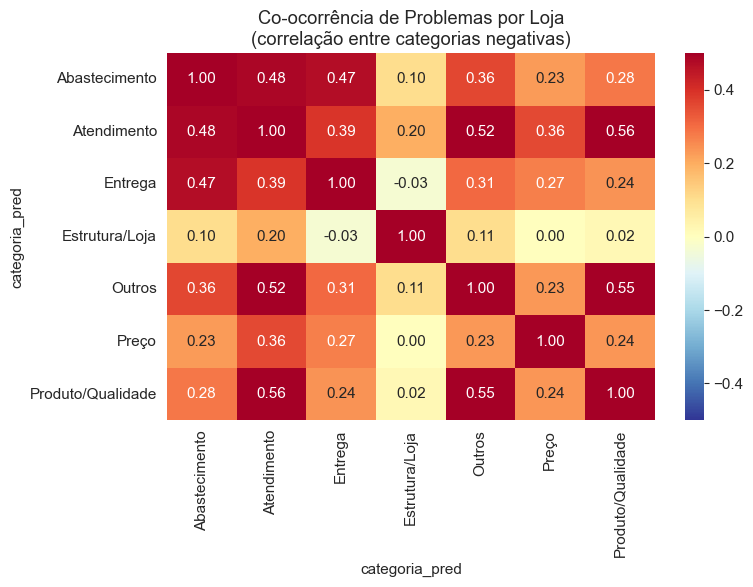

Pares de problemas que tendem a aparecer JUNTOS:
  Abastecimento + Atendimento: r=0.48
  Abastecimento + Entrega: r=0.47
  Abastecimento + Outros: r=0.36
  Atendimento + Entrega: r=0.39
  Atendimento + Outros: r=0.52
  Atendimento + Preço: r=0.36
  Atendimento + Produto/Qualidade: r=0.56
  Entrega + Outros: r=0.31
  Outros + Produto/Qualidade: r=0.55


In [28]:
# 4.1 — Co-ocorrência de categorias por loja
# Quais problemas tendem a aparecer juntos?
loja_problemas = df[df['sentimento_pred']=='Negativo'].groupby(
    ['CentroNv2', 'categoria_pred']).size().unstack(fill_value=0)

# Correlação entre categorias de problemas por loja
corr_problemas = loja_problemas.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_problemas, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, ax=ax, vmin=-0.5, vmax=0.5)
ax.set_title('Co-ocorrência de Problemas por Loja\n(correlação entre categorias negativas)')
plt.tight_layout()
plt.show()

print("Pares de problemas que tendem a aparecer JUNTOS:")
for i in range(len(corr_problemas)):
    for j in range(i+1, len(corr_problemas)):
        if corr_problemas.iloc[i, j] > 0.3:
            print(f"  {corr_problemas.index[i]} + {corr_problemas.columns[j]}: r={corr_problemas.iloc[i,j]:.2f}")

In [29]:
# 4.2 — Tendência de deterioração/melhora por loja
# Calcular slope do NPS mensal por loja (regressão linear simples)
from scipy import stats

tendencias = []
for loja in df['CentroNv2'].unique():
    sub = df[df['CentroNv2'] == loja]
    nps_mensal = sub.groupby('mes_ano').apply(
        lambda x: ((x['classificacao']=='promotor').sum() - (x['classificacao']=='detrator').sum()) / len(x) * 100
    )
    if len(nps_mensal) >= 6:  # mínimo 6 meses
        x_vals = np.arange(len(nps_mensal))
        slope, _, r_value, p_value, _ = stats.linregress(x_vals, nps_mensal.values)
        tendencias.append({
            'Loja': loja,
            'Slope_NPS_mensal': slope,
            'R2': r_value**2,
            'P_value': p_value,
            'Flag': sub['Flag'].mode().iloc[0]
        })

tend_df = pd.DataFrame(tendencias).sort_values('Slope_NPS_mensal')

print("=== LOJAS COM TENDÊNCIA DE DETERIORAÇÃO (slope negativo, p<0.1) ===")
deteriorando = tend_df[(tend_df['Slope_NPS_mensal'] < -0.5) & (tend_df['P_value'] < 0.1)]
print(f"  {len(deteriorando)} lojas detectadas")
if len(deteriorando) > 0:
    print(deteriorando[['Loja', 'Slope_NPS_mensal', 'P_value', 'Flag']].head(10).to_string(index=False))

print(f"\n=== LOJAS COM TENDÊNCIA DE MELHORA (slope positivo, p<0.1) ===")
melhorando = tend_df[(tend_df['Slope_NPS_mensal'] > 0.5) & (tend_df['P_value'] < 0.1)]
print(f"  {len(melhorando)} lojas detectadas")
if len(melhorando) > 0:
    print(melhorando[['Loja', 'Slope_NPS_mensal', 'P_value', 'Flag']].tail(10).to_string(index=False))

=== LOJAS COM TENDÊNCIA DE DETERIORAÇÃO (slope negativo, p<0.1) ===
  11 lojas detectadas
                            Loja  Slope_NPS_mensal  P_value     Flag
                   L5163-TAQUARI         -1.999104 0.005446  REGULAR
                     L5253-HORTO         -1.782724 0.044805 TOCADORA
L5065-LINS DE VASCONCELOS (1313)         -1.757377 0.018251  REGULAR
       L5070-BORGES LAGOA (1323)         -1.710812 0.088879 TOCADORA
             L5149-ALTO DA MOOCA         -1.534584 0.046861  REGULAR
             L5138-306 ASA NORTE         -1.423108 0.024449  REGULAR
      L5048-SJC ANDROMEDA (1261)         -1.166437 0.044375  REGULAR
           L5184-PRACA VARNHAGEM         -1.105717 0.034368  REGULAR
         L5100-INTERLAGOS (1431)         -0.952063 0.099649  REGULAR
          L5230-LARGO DO MACHADO         -0.790827 0.016208  REGULAR

=== LOJAS COM TENDÊNCIA DE MELHORA (slope positivo, p<0.1) ===
  32 lojas detectadas
                             Loja  Slope_NPS_mensal  P_value     

---
# Próximos Passos

1. **Backend:** Substituir `inference.py` mock pelos modelos treinados (`modelo_sentimento_final.pkl` e `modelo_categorizacao_baseline.pkl`).
2. **Inferência:** Usar o modelo final de sentimento escolhido na etapa 1.1; por padrão, `TF-IDF Avançado + Features`.
3. **Novas rotas:** `/dashboard/nps-adjusted`, `/dashboard/business-analysis`, `/dashboard/executive-summary`.
4. **Frontend:** Páginas de NPS Ajustado, Comparativo REGULAR vs TOCADORA, Compilado Executivo.
5. **Deploy:** Atualizar Docker com as dependências de ML necessárias. Se SetFit for usado, incluir `setfit`, `datasets` e `sentence-transformers`.
